In [1]:
## Import all required libraries
import warnings
warnings.filterwarnings('ignore')

import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns  # nicer statistical plots
import anndata as ad
import scimap as sm
from scipy.spatial import cKDTree  # fast neighbor-within-radius search, used by spatial_interaction_working
from scipy.cluster.hierarchy import linkage, dendrogram # clustering for heatmaps

from PIL import Image # Python Imaging Library, used to load a saved image back in
import matplotlib.patches as mpatches  # used to build colored legend squares manually for voronoi

print("✅ All libraries imported successfully.")

Running SCIMAP  2.3.5
✅ All libraries imported successfully.


In [2]:
## ‼️ UPDATE ‼️ this cell when doing new samples or when you want to make a change

working_dir = 'C:/Users/kelse/OneDrive - The Mount Sinai Hospital/02_Presentations/Platforma_MCMICRO_Tutorial_Docs/MCMICRO_Python_Analysis/analysis/'

# one h5ad path per sample -- add/remove entries here depending on how many samples you're comparing
sample_h5ads = {  # ‼️UPDATE‼️ path + name for your 2nd, 3rd, etc... sample
    '41_ST_KO':      f"{working_dir}/scimap_results/adata_tocombine/adata_41_ST_KO.h5ad", 
    '40_ST_KO':  f"{working_dir}/scimap_results/adata_tocombine/adata_40_ST_KO.h5ad",
    'BDBAT0085' : f"{working_dir}/scimap_results/adata_tocombine/adata_BDBAT0085.h5ad"
}

# Column names
phenotype_col = 'phenotype' # column holding cell type labels
roi_col = 'ROI'  # column holding each sample's ORIGINAL roi assignment (Tumor1, Tumor2, Spleen, Tumor, etc -- before we combine samples below)

# ROI naming isn't consistent across samples (ex. one sample has Tumor1/Tumor2/Spleen, another just has Tumor/Spleen)
# so instead of a fixed rois_to_use list, we bucket ROIs into shared categories by keyword (case-insensitive "contains" match)
roi_keywords = {
    'Tumor':  'tumor',   # anything with "tumor" in the name (Tumor1, Tumor2, Tumor...) gets bucketed here
    'Spleen': 'spleen', # same logic
}

# Which category is this run comparing? must be one of the keys in roi_keywords above
category_to_compare = 'Tumor'  # ‼️UPDATE‼️ change to 'Spleen' to run that comparison instead

# Confirm the configuration
print(f"Samples configured: {list(sample_h5ads.keys())}")
print(f"Comparing category: {category_to_compare}")

Samples configured: ['41_ST_KO', '40_ST_KO', 'BDBAT0085']
Comparing category: Tumor


In [3]:
# Several of the commands below require inputs in pixels
# Here is a formula to convert your desired radius in um to pixels

# um to pixel conversion formula:
radius_um = 30  # the radius you want in micrometers
pixel_size_um = 0.65  # your known pixel size -- this shouldn't change

radius_px = radius_um / pixel_size_um

print(f"Radius: {radius_um} um = {radius_px:.1f} pixels")

Radius: 30 um = 46.2 pixels


In [4]:
## Extra custom configuration -- ‼️UPDATE‼️ this cell as well when doing new samples or when you want to make a change

# Spatial interaction radius (pixels)
# 70px is approx 50–100 µm depending on image resolution
interaction_radius = 76.9 ## ‼️UPDATE‼️ based on formula above -- double check pixel_size_um is the same across ALL your samples first,
                           # if it's not, this needs to be computed per sample instead of one shared value

# Where to save plots for this combined analysis (no longer tied to a single sample's working_dir now that we have several)
output_dir = f'{working_dir}/cross_sample_analysis/plots' # ‼️UPDATE‼️

# Voronoi tissue map settings
# NOTE, voronoi_rois / foldchange_from / aggregate_rois below now need to be "sample_roi" names (sample + '_' + original ROI),
# which is built further down in the notebook -- e.g. '41_ST_KO_Tumor1'
voronoi_rois = ['41_ST_KO_Tumor1']    # which region(s) to plot -- one image per entry, add more sample_roi combos as needed
voronoi_save_dir = output_dir
voronoi_size_max = 3000      # max polygon size in pixels^2, -- higher = more filled but more edge spikes
voronoi_max_cells = 15000    # ‼️UPDATE‼️ Voronoi has to compute + draw one polygon per cell, which gets slow
                              # past tens of thousands -- if a region has more cells than this, we randomly
                              # subsample (stratified by phenotype, see below) down to this many before plotting.
                              # Raise for more detail/slower, lower for faster/coarser. Set to None to disable.

# Foldchange settings
foldchange_from = '41_ST_KO_Tumor'   # the reference region, all other regions in THIS run are compared TO this one
foldchange_to  = None  # None = compare against ALL other regions in this run automatically, can also set to (ex.) 'SAMPLE2_NAME_Tumor' to compare just 1 pair
foldchange_label = 'foldchange_roi' # name to store the results under inside adata1

# Spatial distance settings
distance_from = 'Tumor cells' # the cell type to measure FROM
distance_to  = [
    'neutrophils',
    'PDL1 cells',
    'PD1 cells',
    'M2 Macs',
    'M1 Macs',
    'Epithilial cells',
    'Dendritic cells',
    'CD8+ T cells',
    'CD4+ T cells',
]
# the cell types to measure TO

# Immune-immune interaction settings -- used by the immune-only interaction heatmap below,
# so you can see how immune cell types interact with EACH OTHER instead of just with Tumor cells
immune_phenotypes = [
    'Immune cells',
    'Myeloid cells',
    'Lymphoid cells',
    'neutrophils',
    'Macrophages',
    'Dendritic cells',
    'M1 Macs',
    'M2 Macs',
    'T cells',
    'NK cells',
    'CD4+ T cells',
    'CD8+ T cells',
    'PD1 cells',
    'PDL1 cells', # macrophages (and other immune cells) can be PDL1+, so this isn't tumor-exclusive
]
# ‼️UPDATE‼️ if you add/rename phenotypes -- excludes Tumor cells and Epithilial cells since
# those are separate top-level categories in the phenotyping workflow that are never immune
# (unlike PDL1 cells, which can be expressed on immune cells too)


# Spatial aggregate settings
aggregate_rois = ['41_ST_KO_Tumor'] # which region(s) to plot the aggregate voronoi for -- one image per entry
aggregate_radius = 46.2  # search radius in pixels -- how far to look for neighbors ## ‼️UPDATE‼️based on formula above
aggregate_purity = 80  # minimum % of neighbors that must be the same cell type to call a region "pure"
aggregate_label = 'spatial_aggregate'  # name for the new column added to adata1.obs


# Confirm the configuration
print(f"Save directory: {voronoi_save_dir}")

Save directory: C:/Users/kelse/OneDrive - The Mount Sinai Hospital/02_Presentations/Platforma_MCMICRO_Tutorial_Docs/MCMICRO_Python_Analysis/analysis//cross_sample_analysis/plots


In [5]:
# Load each sample's phenotyped adata (saved at the end of step 1) and combine into one object
# ad.concat's label= param automatically adds a new obs column recording which sample each cell came from
adata = ad.concat(
    {name: ad.read_h5ad(path) for name, path in sample_h5ads.items()},
    label='sample',       # new column: which sample each cell came from
    index_unique='-'      # appends the sample name to each cell's index so cell barcodes can't collide across samples
)

print(adata)
print('\nCells per sample:')
print(adata.obs['sample'].value_counts())
print('\nCell type counts (alphabetical, easier to spot near-duplicate spellings before canonicalizing below):')
print(adata.obs[phenotype_col].value_counts().sort_index())
print('\nOriginal ROI counts per sample (before we combine names below):')
print(adata.obs.groupby('sample')[roi_col].value_counts())

AnnData object with n_obs × n_vars = 1773096 × 6
    obs: 'X_centroid', 'Y_centroid', 'Area', 'MajorAxisLength', 'MinorAxisLength', 'Eccentricity', 'Solidity', 'Extent', 'Orientation', 'CellID', 'imageid', 'Treatment_Group', 'phenotype', 'ROI', 'genotype', 'sample'
    layers: 'log'

Cells per sample:
sample
40_ST_KO     1014437
41_ST_KO      692343
BDBAT0085      66316
Name: count, dtype: int64

Cell type counts (alphabetical, easier to spot near-duplicate spellings before canonicalizing below):
phenotype
CD4 T cells         142708
CD4+ T cells          1766
CD8 T cells         119459
CD8+ T cells          5997
Dendritic cells     270798
Epithilial cells     28021
Immune cells         45733
Lymphoid cells      248528
M1 Macs             472714
M2 Macs              24524
Macrophages         232175
Myeloid cells        54591
NK cells             19800
PD1 cells              106
PDL1 cells           10647
T cells              15815
Tumor                33270
Tumor cells          43684
ne

In [6]:
## Canonicalize phenotype names across samples before anything else uses phenotype_col --
## fixes spelling differences at once so customColors, distance_from/distance_to, foldchange, etc. all are clearer

# First, look at the list of cell types (pooled, raw) in the output of the cell above

# Map every variant spelling to ONE canonical name -- EXACT match only, have to edit this yourself

phenotype_rename = {
    'Tumor': 'Tumor cells',   # bdbat0085 says 'Tumor', KS_2 samples say 'Tumor cells'
    'CD8 T cells':  'CD8+ T cells',   # ‼️UPDATE‼️ add every variant spelling you find in the printout above
    'CD4 T cells':  'CD4+ T cells',   
}

adata.obs[phenotype_col] = adata.obs[phenotype_col].replace(phenotype_rename)
print("Variant spellings fixed!")
print('\nCell type counts (alphabetical, easier to spot near-duplicates than sorted by count):')
print(adata.obs[phenotype_col].value_counts().sort_index())

# Sanity check, part 1: catch spellings that phenotype_rename above missed. Groups names by a
# normalized form (lowercase, letters/digits only -- strips spaces, +/-, punctuation) and
# flags any group where more than one distinct spelling survived, since those are almost
# certainly the same cell type under different names that slipped through the rename dict
# above (e.g. 'CD8 T cells' vs 'CD8+T cells' vs 'CD8+ T Cells')
normalized_groups = {}
for name in adata.obs[phenotype_col].unique():
    key = re.sub(r'[^a-z0-9]', '', name.lower())
    normalized_groups.setdefault(key, set()).add(name)

unharmonized = {key: names for key, names in normalized_groups.items() if len(names) > 1}

if unharmonized:
    print("\n⚠️ Possible unharmonized phenotype spellings -- add these to phenotype_rename above:")
    for names in unharmonized.values():
        print(f"  {sorted(names)}")
else:
    print("\n✅ No unharmonized phenotype spellings detected.")

# Sanity check, part 2: catch near-misses where one name is a PREFIX of another (e.g. 'Tumor'
# vs 'Tumor cells') -- lower confidence than part 1 above, just a "worth a second look" flag,
# since a short name could legitimately be its own parent category of a longer one (e.g.
# 'T cells' vs 'CD8+ T cells' in this gating hierarchy) -- those don't share a prefix
# starting from position 0 though, so they won't trigger this check
unique_names = sorted(adata.obs[phenotype_col].unique(),
                       key=lambda n: re.sub(r'[^a-z0-9]', '', n.lower()))
normalized_names = [re.sub(r'[^a-z0-9]', '', n.lower()) for n in unique_names]

prefix_flags = []
for i in range(len(unique_names)):
    for j in range(i + 1, len(unique_names)):
        shorter, longer = sorted([normalized_names[i], normalized_names[j]], key=len)
        if shorter and longer.startswith(shorter):
            prefix_flags.append((unique_names[i], unique_names[j]))

if prefix_flags:
    print("\n👀 Possible near-miss spellings (one name is a prefix of the other) -- worth a second look:")
    for name_a, name_b in prefix_flags:
        print(f"  {name_a!r} vs {name_b!r}")
else:
    print("\n✅ No prefix-style near-misses detected.")

# Colors -- NOW these have to match your phenotype names exactly (safe to define here since names are canonicalized above)
customColors = {
    'M1 Macs':          '#118ab2',
    'Dendritic cells':  '#ffd166',
    'Macrophages':      '#06d6a0',
    'Tumor cells':      '#ef476f',
    'CD8+ T cells':      '#073b4c',
    'Myeloid cells':    '#ff9f1c',
    'CD4+ T cells':      '#7209b7',
    'Epithilial cells': '#4cc9f0',
    'M2 Macs':          '#80ed99',
    'Lymphoid cells':   '#f15bb5',
    'T cells':          '#9b5de5',
    'Immune cells':     '#00bbf9',
    'PDL1 cells':       '#fee440',
    'neutrophils':      '#fb5607',
    'NK cells':         '#3a86ff',
    'PD1 cells':        '#8338ec',
}

Variant spellings fixed!

Cell type counts (alphabetical, easier to spot near-duplicates than sorted by count):
phenotype
CD4+ T cells        144474
CD8+ T cells        125456
Dendritic cells     270798
Epithilial cells     28021
Immune cells         45733
Lymphoid cells      248528
M1 Macs             472714
M2 Macs              24524
Macrophages         232175
Myeloid cells        54591
NK cells             19800
PD1 cells              106
PDL1 cells           10647
T cells              15815
Tumor cells          76954
neutrophils           2760
Name: count, dtype: int64

✅ No unharmonized phenotype spellings detected.

✅ No prefix-style near-misses detected.


In [7]:
# Combine sample + original ROI into one identifier so each physical region stays distinct below
# (Tumor1 and Tumor2 are different regions within the same sample, and Tumor in another sample is a third,
# separate region -- we don't want cells from different regions getting pooled together in the spatial calcs)
adata.obs['sample_roi'] = adata.obs['sample'].astype(str) + '_' + adata.obs['ROI'].astype(str)

# Bucket each ROI into a shared category by keyword (case-insensitive "contains" match), since naming isn't
# consistent across samples -- this is what lets Tumor1 / Tumor2 / Tumor get compared as the same "type" of region
def categorize_roi(roi_name, keywords):
    roi_lower = roi_name.lower()
    for category, keyword in keywords.items():
        if keyword in roi_lower:
            return category
    return 'Other' # didn't match any keyword

adata.obs['roi_category'] = adata.obs[roi_col].apply(lambda x: categorize_roi(x, roi_keywords))

# Point roi_col at the new combined identifier -- everything below this cell still just references
# the variable roi_col, so none of it needs to change
roi_col = 'sample_roi'

# Filter down to just the category we're comparing this run (‼️UPDATE‼️ category_to_compare above to switch)
rois_to_use = sorted(adata.obs.loc[adata.obs['roi_category'] == category_to_compare, roi_col].unique().tolist())

adata1 = adata[adata.obs[roi_col].isin(rois_to_use)].copy() # grab roi_col, turn into true/false list (boolean mask), keep only true rows

print(f'Comparing category: {category_to_compare}')
print(f'Regions included: {rois_to_use}')
print(f'\nTotal cells in these regions: {adata1.n_obs:,}')
print('\nCells per region:')
print(adata1.obs[roi_col].value_counts()) # how many cells of each region



Comparing category: Tumor
Regions included: ['40_ST_KO_Tumor', '41_ST_KO_Tumor', '41_ST_KO_Tumor2']

Total cells in these regions: 337,804

Cells per region:
sample_roi
41_ST_KO_Tumor     208812
41_ST_KO_Tumor2     85924
40_ST_KO_Tumor      43068
Name: count, dtype: int64


In [8]:
# Sanity check, confirm every phenotype name your config cells reference actually exists in adata1 --
# catches spelling mismatches immediately instead of silently producing empty/wrong plots downstream
# (same root cause as the napari bug just for phenotype names instead of ROI names)
actual_phenotypes = set(adata1.obs[phenotype_col].unique())
config_phenotypes = {distance_from, *distance_to, *customColors.keys()}
missing = config_phenotypes - actual_phenotypes

if missing:
    print(f"Config references phenotypes not found in adata1: {missing}")
    print(f"Actual phenotypes present: {sorted(actual_phenotypes)}")
else:
    print("All config phenotype names match what's in adata1!")

All config phenotype names match what's in adata1!


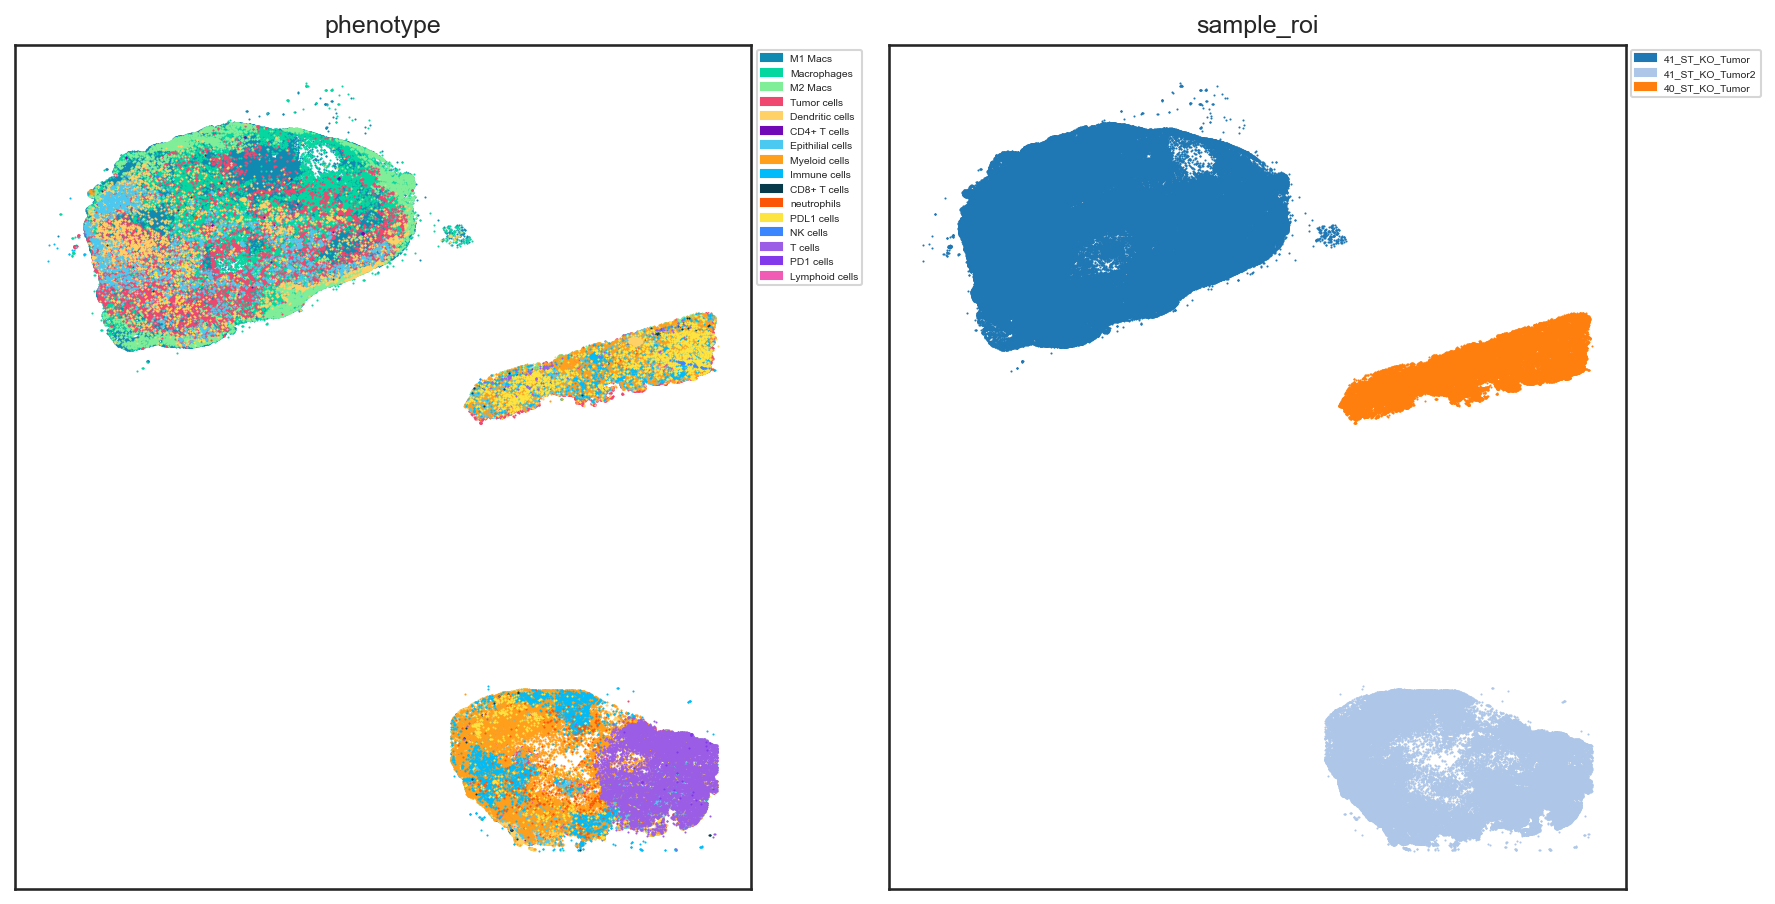

phenotype
M1 Macs             472714
Dendritic cells     270798
Lymphoid cells      248528
Macrophages         232175
CD4+ T cells        144474
CD8+ T cells        125456
Tumor cells          76954
Myeloid cells        54591
Immune cells         45733
Epithilial cells     28021
M2 Macs              24524
NK cells             19800
T cells              15815
PDL1 cells           10647
neutrophils           2760
PD1 cells              106
Name: count, dtype: int64
sample_roi
40_ST_KO_Spleen    971369
41_ST_KO_Spleen    397607
41_ST_KO_Tumor     208812
41_ST_KO_Tumor2     85924
40_ST_KO_Tumor      43068
BDBAT0085_ROI1      22994
BDBAT0085_ROI3      16916
BDBAT0085_ROI2      16012
BDBAT0085_ROI4      10394
Name: count, dtype: int64


In [9]:
## Whole tissue scatter plot -- view of the entire tissue colored by cell type + ROI side by side
sm.pl.spatial_scatterPlot( # scimap func, plots cells at their X/Y positions
    adata=adata1,
    colorBy=[phenotype_col, roi_col],# make 2 plots side by side: one colored by cell type, one by ROI
    figsize=(12, 12),
    s=1, # dot size -- small here
    plotLegend=True, # show color legend
    fontsize=5,
    dpi=150,
    customColors=customColors # use our defined color names
)

print(adata.obs[phenotype_col].value_counts())
print(adata.obs[roi_col].value_counts())

--40_ST_KO_Tumor--


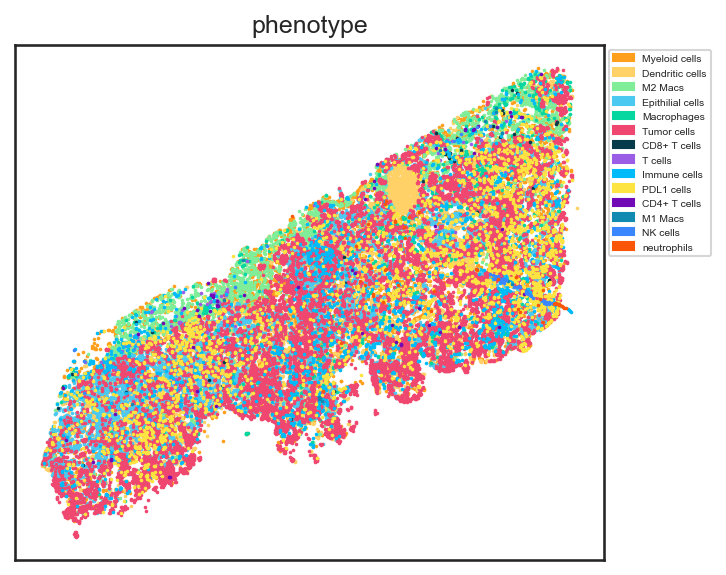

--41_ST_KO_Tumor--


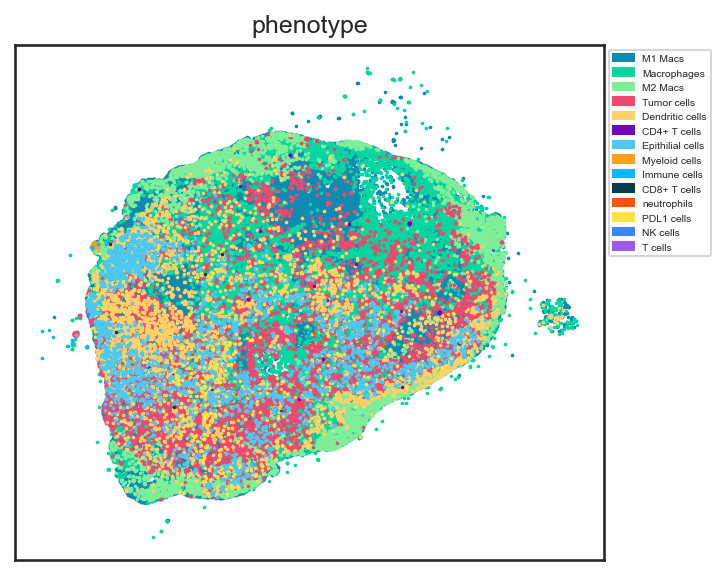

--41_ST_KO_Tumor2--


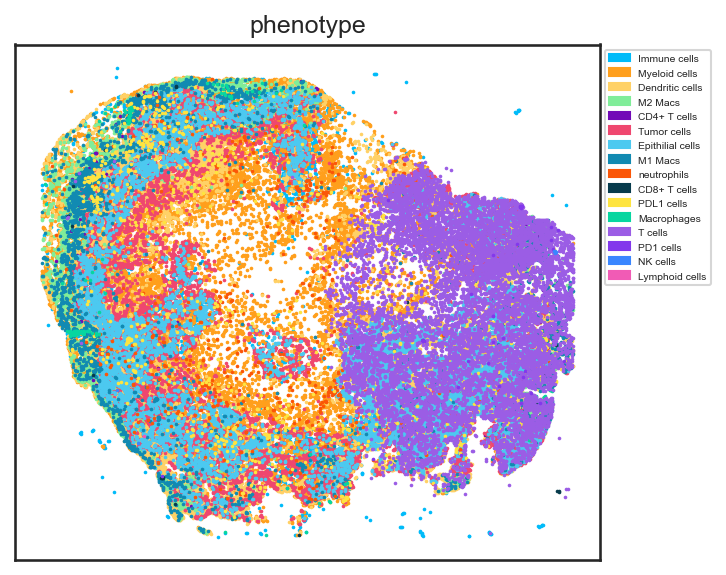

In [10]:
## Same scatter but zoomed into each ROI individually, useful for comparing immune composition between tissue regions 
for roi in rois_to_use:  # loop through each ROI one at a time
    print(f'--{roi}--')
    sm.pl.spatial_scatterPlot(
        adata=adata1,
        colorBy=[phenotype_col],
        imageid=roi_col, # tells scimap the ROI column defines separate images
        subset=roi, # only plot THIS one ROI
        figsize=(5, 4),
        s=3,
        plotLegend=True,
        fontsize=5,
        dpi=150,
        customColors=customColors
    )

In [11]:
## Foldchange, part 1
# First compute the foldchange -- this scimap func looks at how many cells of each type are in each ROI
# and computes log2 fold change compared to the ref ROI (foldchange_from)
# Also runs a Fisher's exact test per cell type to see if the difference
# is statistically significant, then corrects for multiple comparisons

print('foldchange_from set to:', repr(foldchange_from))
print('Actual regions in adata1:', sorted(adata1.obs[roi_col].unique()))
print('Match found:', foldchange_from in adata1.obs[roi_col].unique())
adata1 = sm.tl.foldchange(
    adata1,
    from_group=foldchange_from,  # the reference ROI to compare everything against
    to_group=foldchange_to,  
    imageid=roi_col, # column that identifies the ROIs 
    phenotype=phenotype_col, # column w/ the cell type labels 
    normalize=True,  # normalize cell counts by total cells in each ROI
                     # important b/c without this, a bigger ROI would always look like it has more cells 
                     # normalization makes ROIs comparable reregardlessgarldess of size
    label=foldchange_label # where to store results inside adata1
)

print('Foldchange computed!')
print(f'Results stored in adata1.uns["{foldchange_label}"]')


foldchange_from set to: '41_ST_KO_Tumor'
Actual regions in adata1: ['40_ST_KO_Tumor', '41_ST_KO_Tumor', '41_ST_KO_Tumor2']
Match found: True
calculating foldchange
calculating P values
Foldchange computed!
Results stored in adata1.uns["foldchange_roi"]


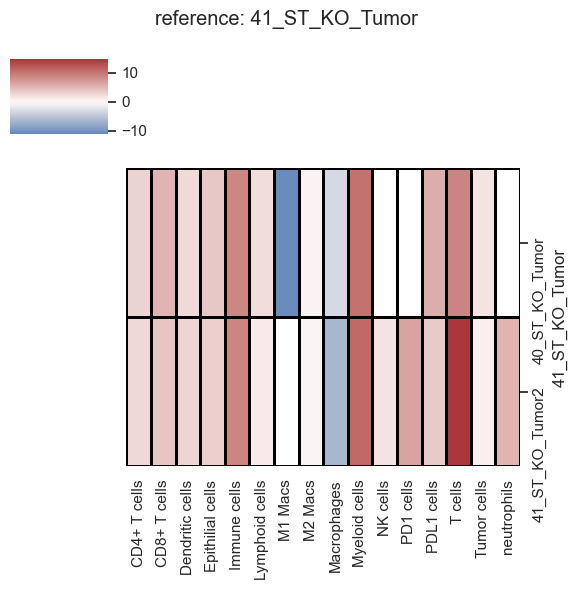

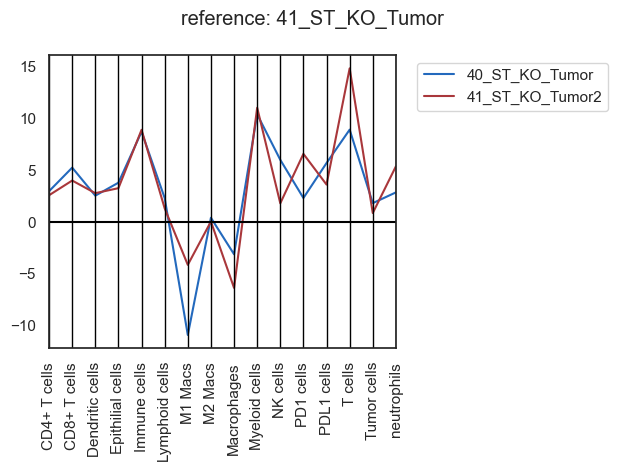

In [12]:
# Foldchange, part 2: plot as a heatmap 
# each row is one cell type, each column is one ROI being compared to the ref ROI
# color = log2 fold change:
# red means this cell type is more abundant in that ROI vs ref and blue means less
# grey means the difference is not statistically significant 
sm.pl.foldchange(
    adata1,
    label=foldchange_label,  # which stored result to plot (must match label above)
    method='heatmap', # display as a heatmap (alternative: 'parallel_coordinates', shown as example on scimap website)
    p_val=0.05,  # significance threshold 
    nonsig_color='grey',   # color for not significant cells in the heatmap
    log=True, # plot log2 fold change 
    figsize=(6, 6),          
    linecolor='black',        
    linewidths=1,
    row_cluster=False,
    col_cluster=False # set these to true if you have 3+ ROIs, otherwise the dendrogram (clutsering) won't work
)

sm.pl.foldchange(
    adata1,
    label=foldchange_label,  # which stored result to plot (must match label above)
    method='parallel_coordinates', # alternate plot type
    p_val=0.05,  # significance threshold 
    nonsig_color='grey',   # color for not significant cells in the heatmap
    log=True # plot log2 fold change         
)

In [13]:
## Scimap spatial interaction
# Computed by comparing real neighbor counts to 100 random permutations; runs separately for each ROI so can take a few mins
adata1 = sm.tl.spatial_interaction( # tests if cell types neighbor each other more/less than chance
    adata1,
    method='radius', #define neighbors by distance (versus 'knn' which is a fixed number of neighbors)
    radius=interaction_radius, # what we defined as "neighbor" distance
    permutation=100, # number of random permutations to compare against -- lower = faster, less precise p-values
    imageid=roi_col, 
    phenotype=phenotype_col,
    label='spatial_interaction_radius' #name to store the results under in adata1
)

Processing Image: ['41_ST_KO_Tumor']
Identifying neighbours within 76.9 pixels of every cell
Mapping phenotype to neighbors
Performing 100 permutations
Consolidating the permutation results
Processing Image: ['41_ST_KO_Tumor2']
Identifying neighbours within 76.9 pixels of every cell
Mapping phenotype to neighbors
Performing 100 permutations
Consolidating the permutation results
Processing Image: ['40_ST_KO_Tumor']
Identifying neighbours within 76.9 pixels of every cell
Mapping phenotype to neighbors
Performing 100 permutations
Consolidating the permutation results


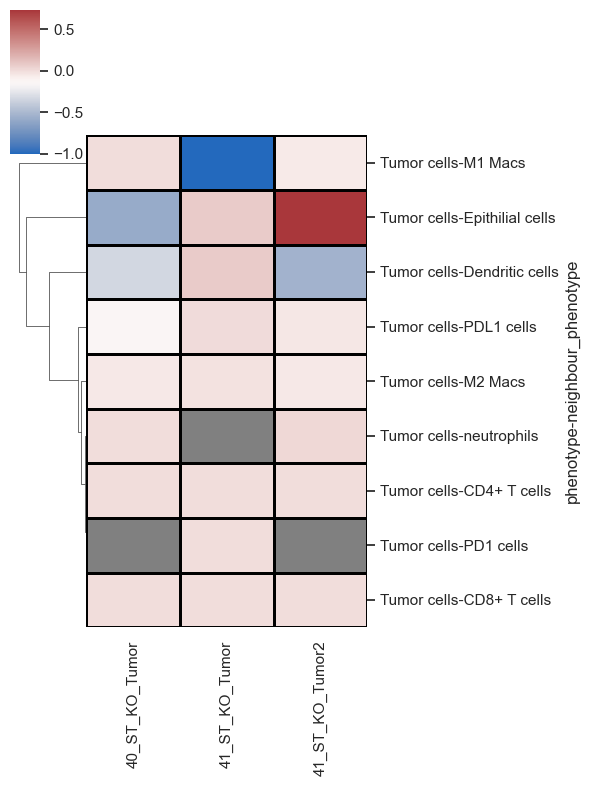

In [14]:
## Plot the results from the previous cell
# Red --> 2 cell types neighbor each other more than chance
# Blue --> they neighbor each other less than chance
# Grey --> no significant relationship
# Each column is 1 region, compare patterns across samples/regions

# Restricted to distance_from -> distance_to (your curated list of cell types of interest,
# already defined in config) instead of the full phenotype x phenotype grid
sm.pl.spatial_interaction(
    adata1,
    spatial_interaction='spatial_interaction_radius',
    subset_phenotype=[distance_from], # only rows where the "center" cell is this type
    subset_neighbour_phenotype=distance_to, # only these neighbor types -- same curated list used in the distance section
    yticklabels=True, # show the cell pair labels on the y axis
    figsize=(6, 8),
    row_cluster=True, # group rows with similar patterns together
    summarize_plot=False, # keep each region as its own column so samples/regions stay comparable side by side
    linewidths=0.75,
    linecolor='black'
)

=== Immune cells ===


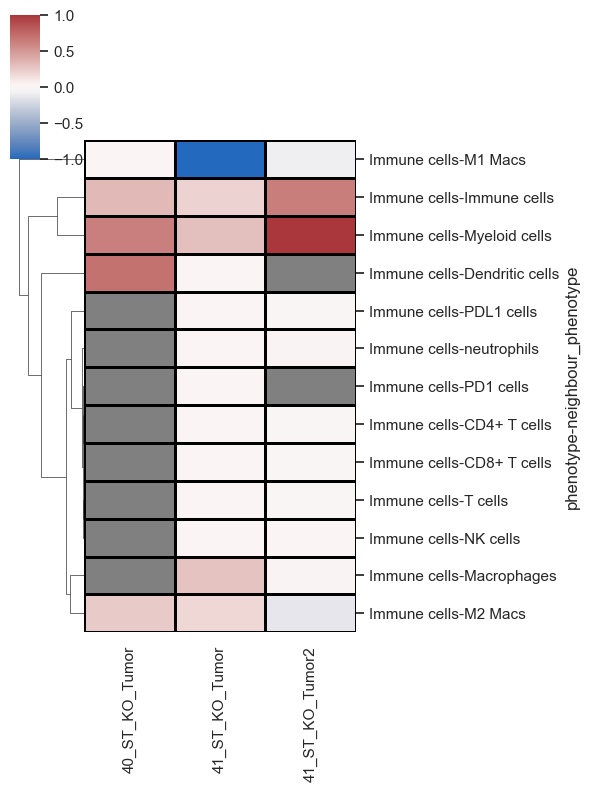

=== Myeloid cells ===


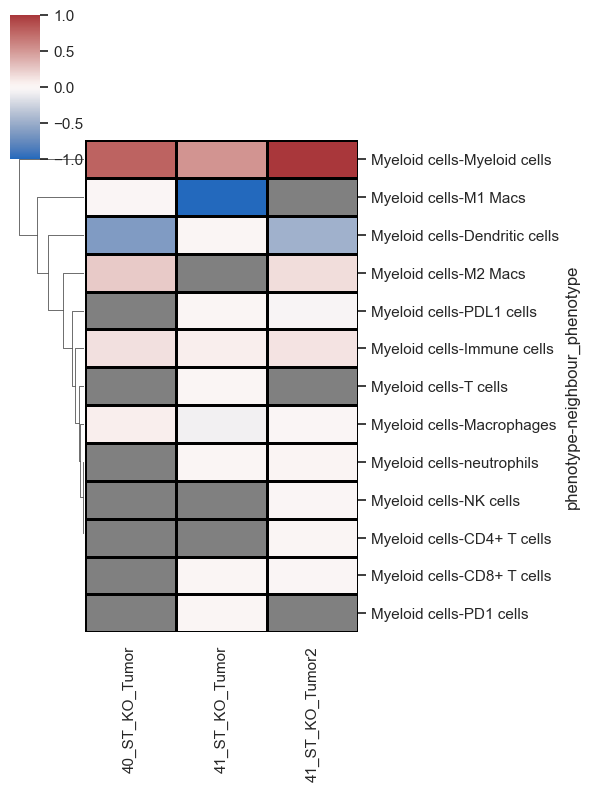

=== Lymphoid cells ===
  (skipped -- The number of observations cannot be determined on an empty distance matrix.)
=== neutrophils ===


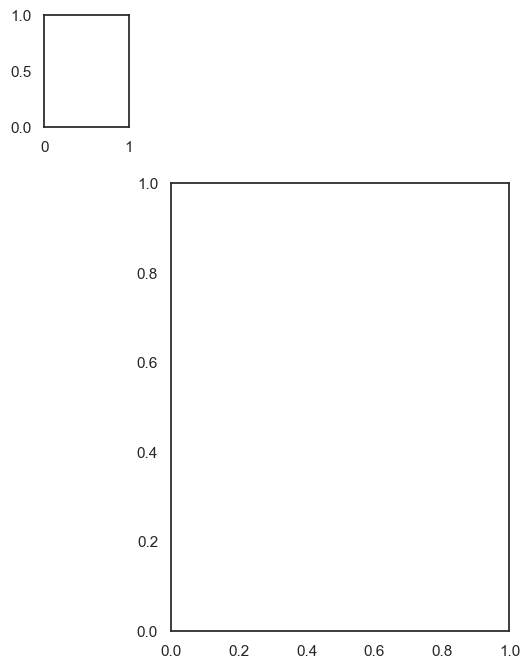

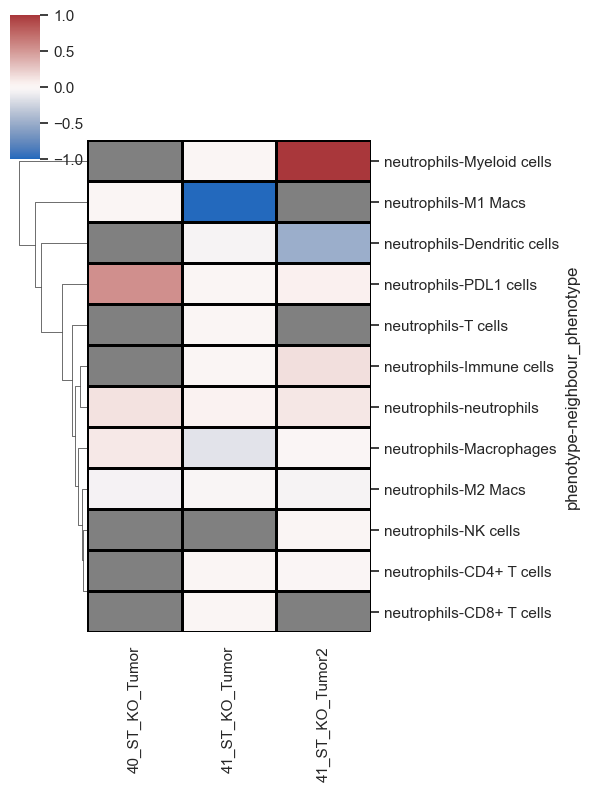

=== Macrophages ===


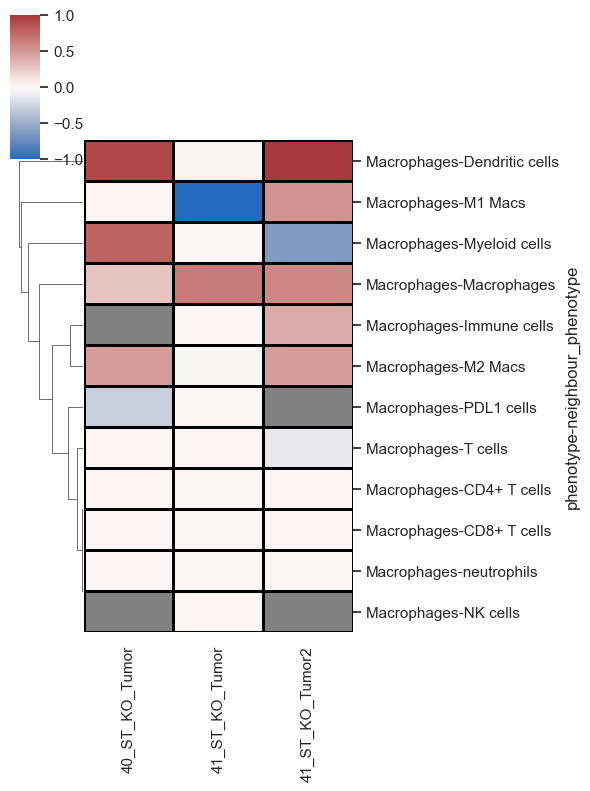

=== Dendritic cells ===


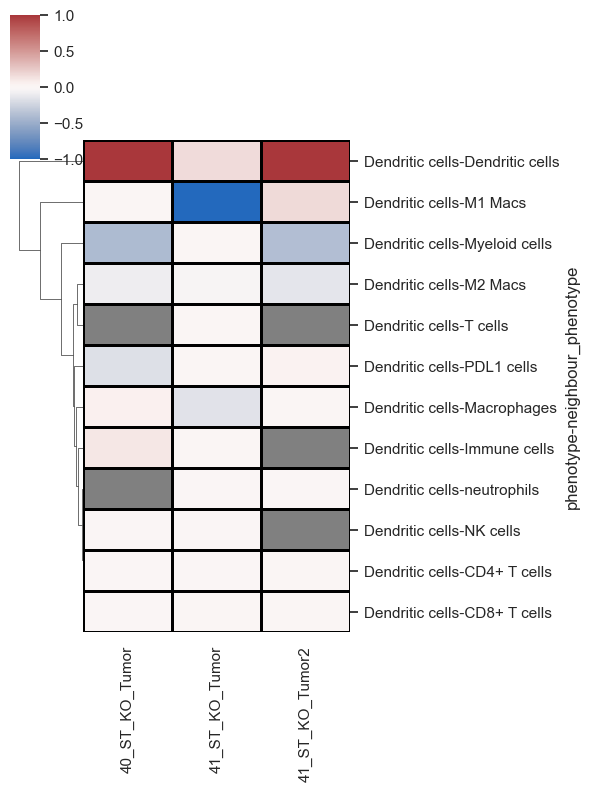

=== M1 Macs ===


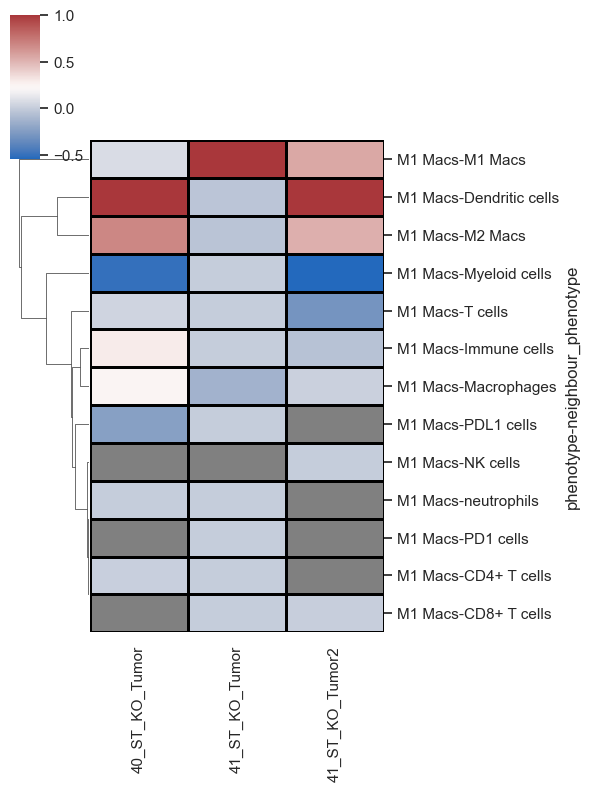

=== M2 Macs ===


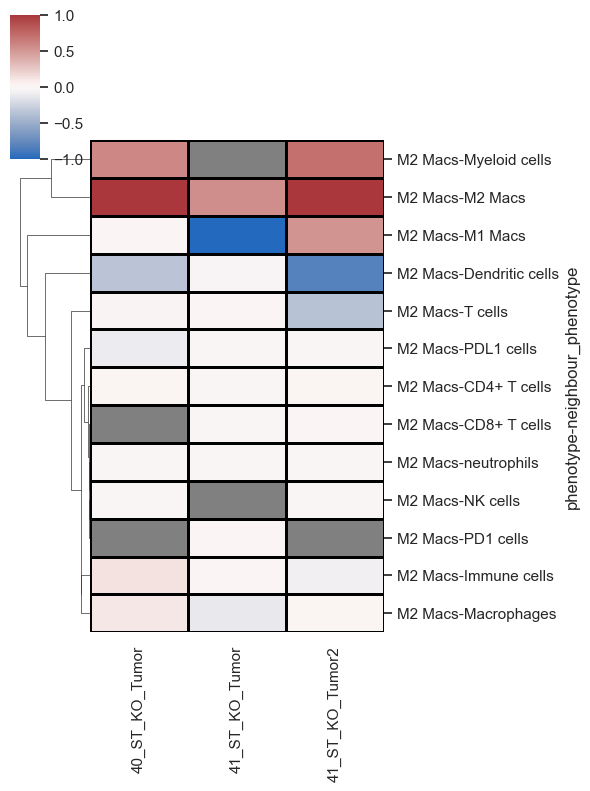

=== T cells ===


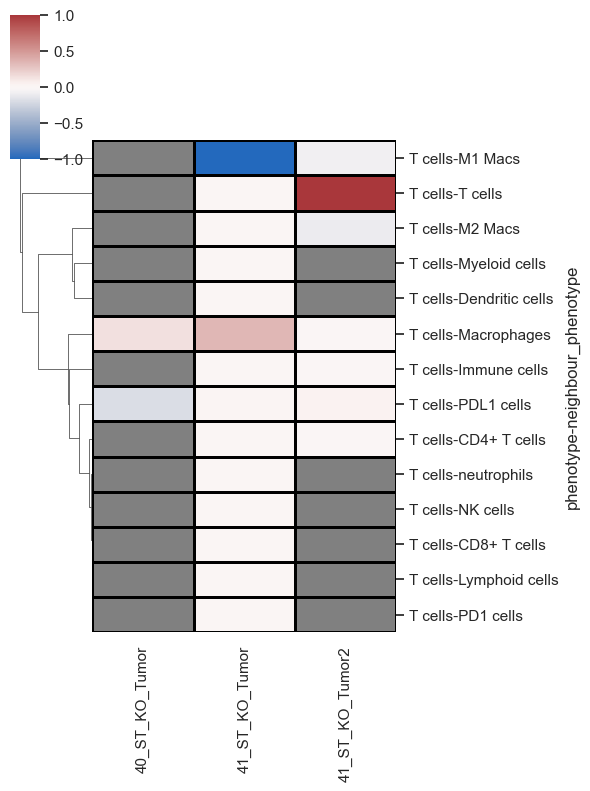

=== NK cells ===


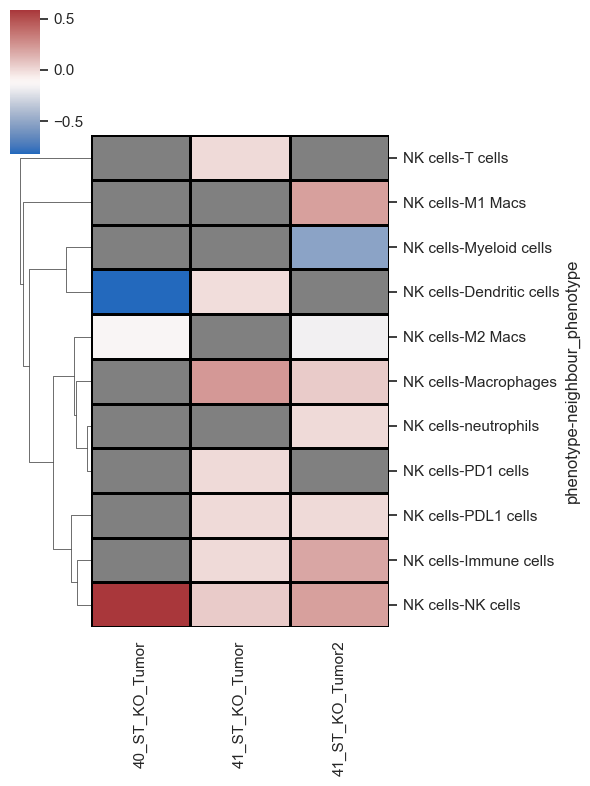

=== CD4+ T cells ===


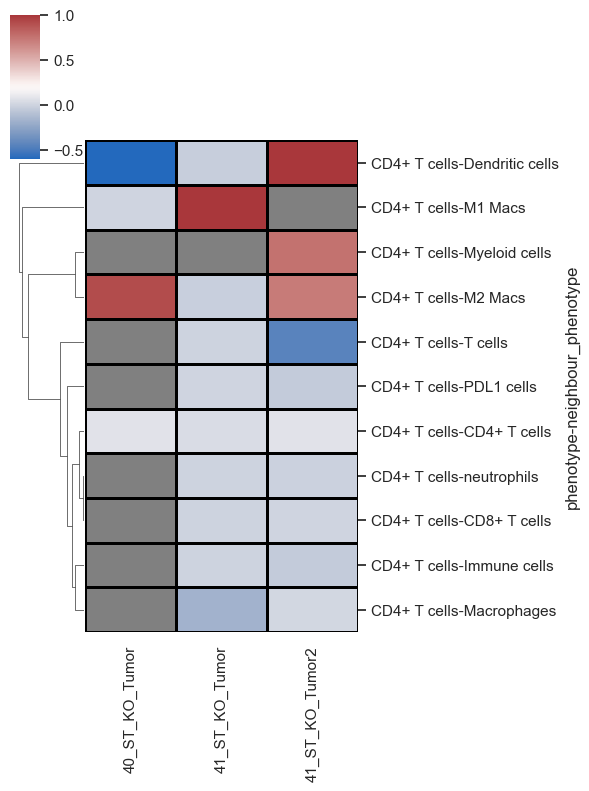

=== CD8+ T cells ===


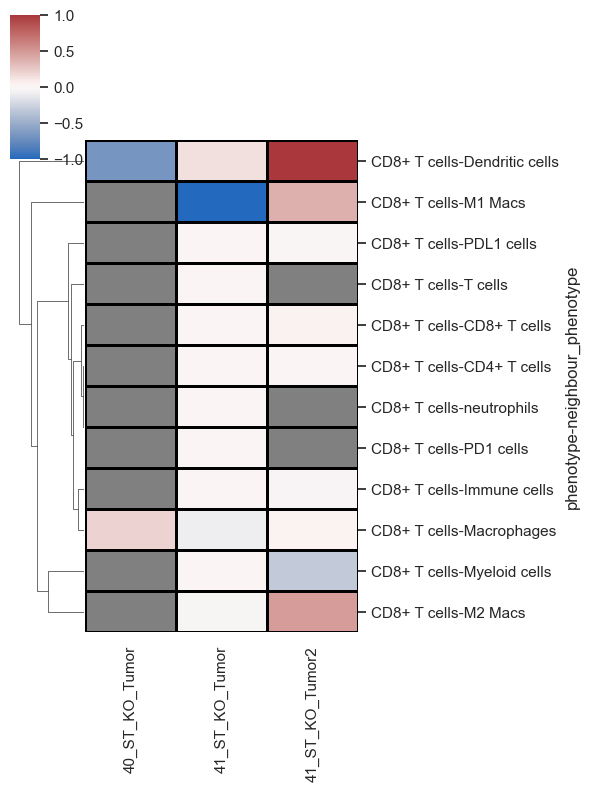

=== PD1 cells ===


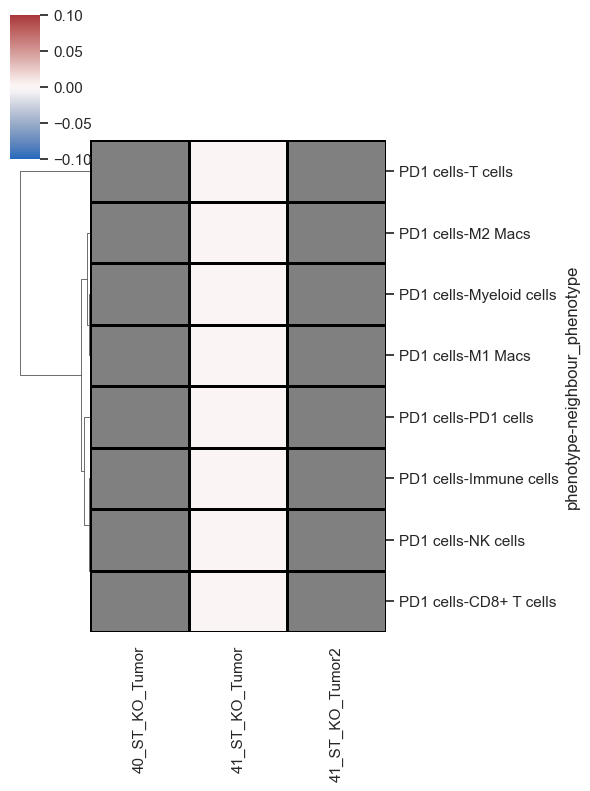

=== PDL1 cells ===


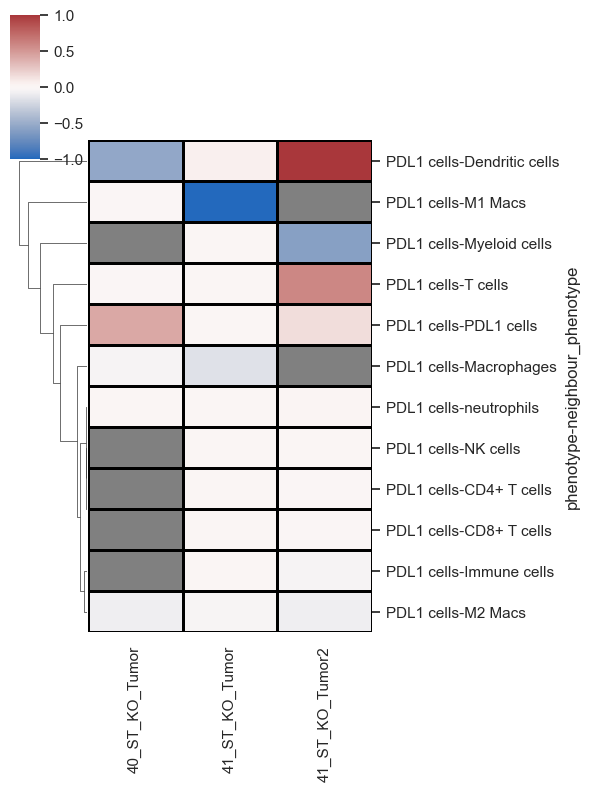

In [16]:
## Same idea as the tumor-immune plot above, but broken out one immune cell type at a time

full_interaction_results = adata1.uns['spatial_interaction_radius']
pval_cols = [c for c in full_interaction_results.columns if c.startswith('pvalue_')]

for phenotype in immune_phenotypes:
    rows = full_interaction_results[full_interaction_results['phenotype'] == phenotype]
    significant_mask = (rows[pval_cols] <= 0.05).any(axis=1)  # matches sm.pl.spatial_interaction's default p_val=0.05
    present_neighbours = rows.loc[significant_mask, 'neighbour_phenotype'].unique()
    neighbours_to_plot = [p for p in immune_phenotypes if p in present_neighbours]

    if not neighbours_to_plot:
        print(f'=== {phenotype} === (skipped -- no significant interactions with any immune_phenotypes)')
        continue

    print(f'=== {phenotype} ===')
    try:
        sm.pl.spatial_interaction(
            adata1,
            spatial_interaction='spatial_interaction_radius',
            subset_phenotype=[phenotype], # this cell type as the "center" cell
            subset_neighbour_phenotype=neighbours_to_plot, # only significant neighbor types for this phenotype
            yticklabels=True, # show the cell pair labels on the y axis
            figsize=(6, 8),
            row_cluster=True, # group rows with similar patterns together
            summarize_plot=False, # keep each region as its own column so samples/regions stay comparable side by side
            linewidths=0.75,
            linecolor='black'
        )
    except ValueError as e:
        # belt-and-suspenders -- catches any remaining edge case in scimap's internal
        # filtering logic we didn't anticipate, so one weird cell type can't kill the loop
        print(f'  (skipped -- {e})')

In [17]:
## Compute spatial distances 
# For each cell in the dataset, this finds the nearest cell of each OTHER type
# Results are stored inside adata1 for plotting below

adata1 = sm.tl.spatial_distance(
    adata1,
    x_coordinate='X_centroid',  
    y_coordinate='Y_centroid',   
    phenotype=phenotype_col,     
    imageid=roi_col, # column identifying the ROI -- runs separately per ROI so we can compare distances across ROIs
    label='spatial_distance' # name to store results under in adata1
)

print('Spatial distances computed!')
print('Results stored in adata1.uns["spatial_distance"]')

Processing Image: 41_ST_KO_Tumor
Processing Image: 41_ST_KO_Tumor2
Processing Image: 40_ST_KO_Tumor
Spatial distances computed!
Results stored in adata1.uns["spatial_distance"]


In [18]:
# Get the ROI for each cell
spatial_dist_df = adata1.uns['spatial_distance'].copy()
spatial_dist_df['ROI'] = adata1.obs[roi_col].values

# Now group by ROI and describe
#spatial_dist_df.groupby('ROI').describe()

spatial_dist_df.groupby('ROI').mean()

print(adata1.obs[roi_col].unique())

['41_ST_KO_Tumor' '41_ST_KO_Tumor2' '40_ST_KO_Tumor']



--Distance to neutrophils--


<Figure size 1000x400 with 0 Axes>

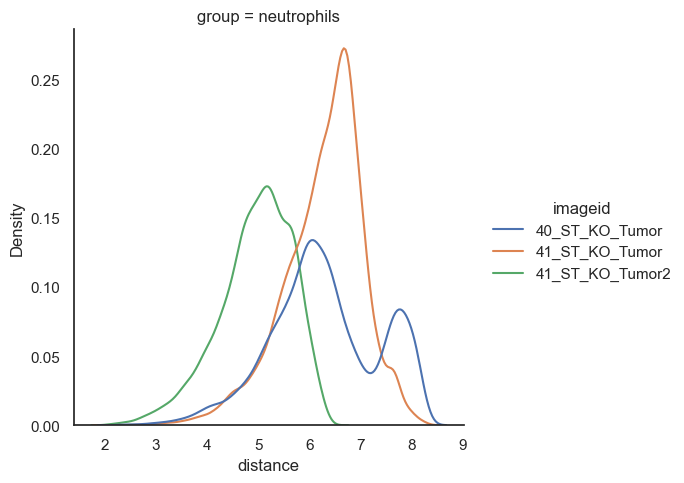

<Figure size 1000x400 with 0 Axes>


--Distance to PDL1 cells--


<Figure size 1000x400 with 0 Axes>

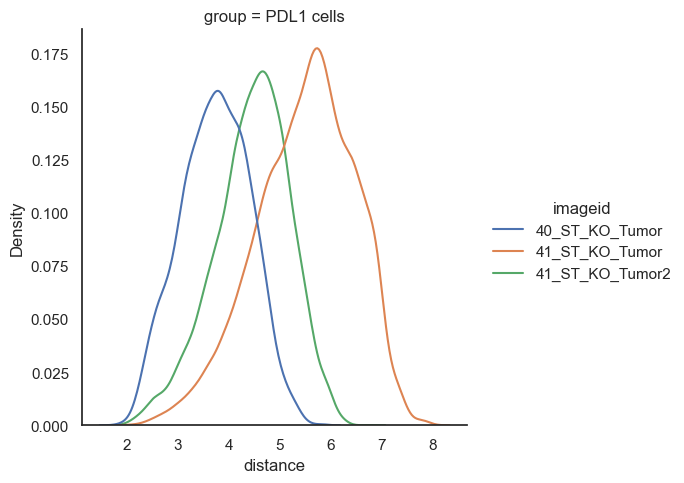

<Figure size 1000x400 with 0 Axes>


--Distance to PD1 cells--


<Figure size 1000x400 with 0 Axes>

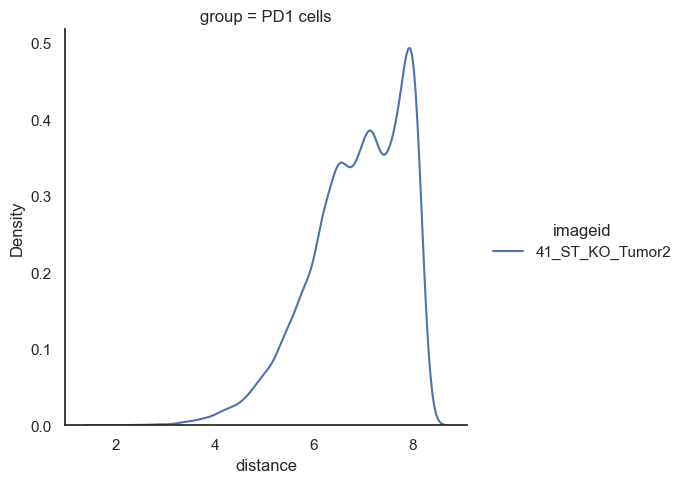

<Figure size 1000x400 with 0 Axes>


--Distance to M2 Macs--


<Figure size 1000x400 with 0 Axes>

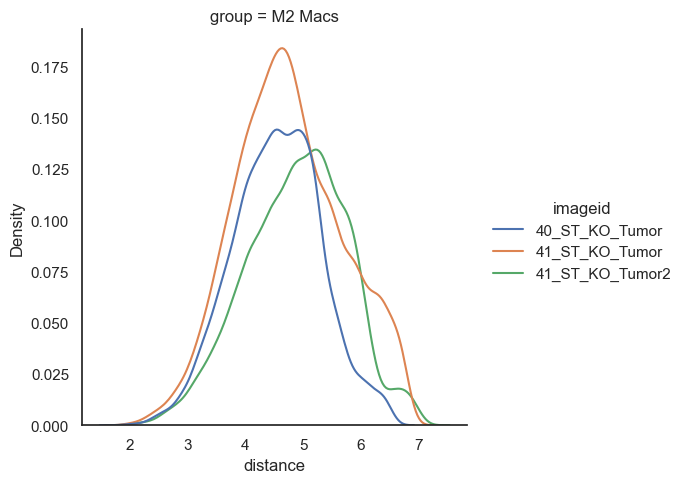

<Figure size 1000x400 with 0 Axes>


--Distance to M1 Macs--


<Figure size 1000x400 with 0 Axes>

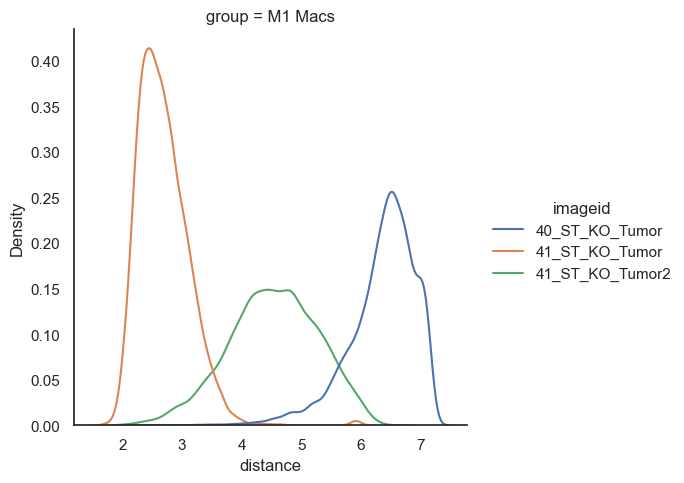

<Figure size 1000x400 with 0 Axes>


--Distance to Epithilial cells--


<Figure size 1000x400 with 0 Axes>

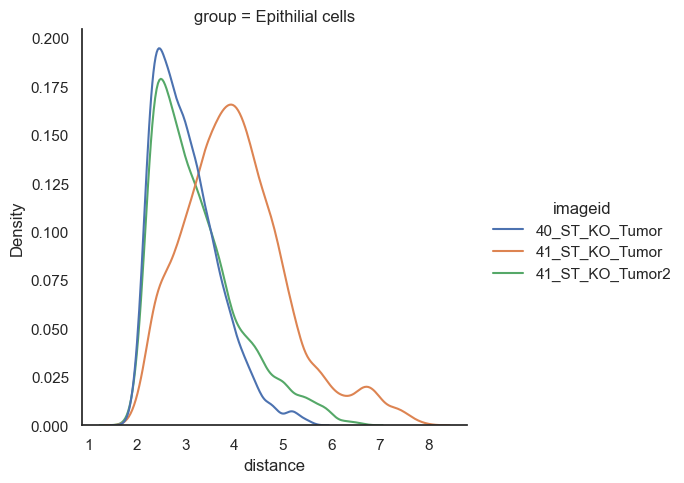

<Figure size 1000x400 with 0 Axes>


--Distance to Dendritic cells--


<Figure size 1000x400 with 0 Axes>

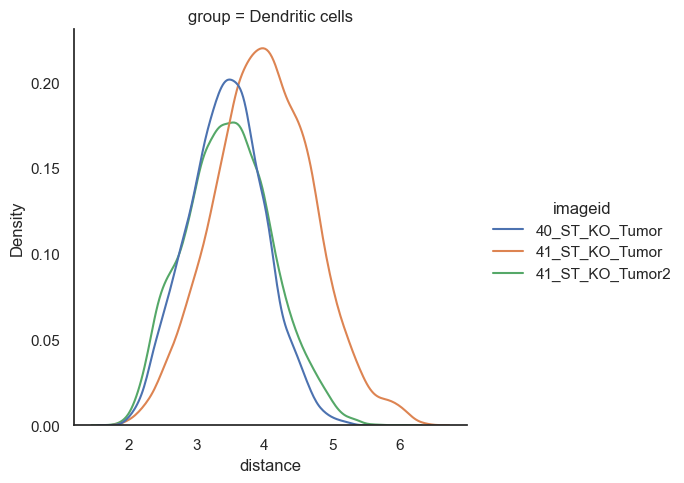

<Figure size 1000x400 with 0 Axes>


--Distance to CD8+ T cells--


<Figure size 1000x400 with 0 Axes>

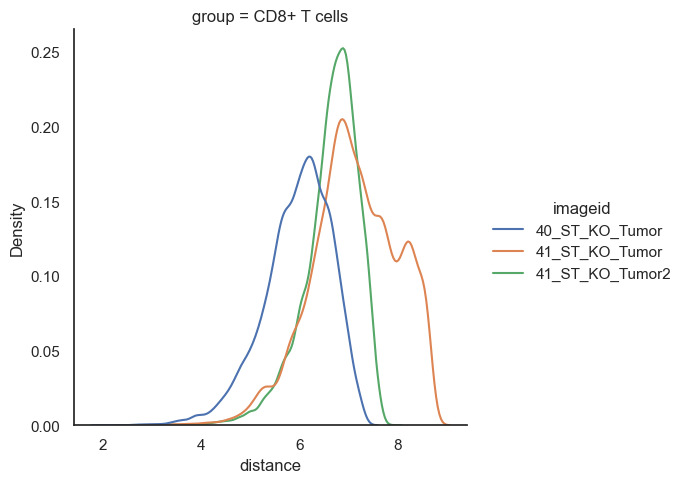

<Figure size 1000x400 with 0 Axes>


--Distance to CD4+ T cells--


<Figure size 1000x400 with 0 Axes>

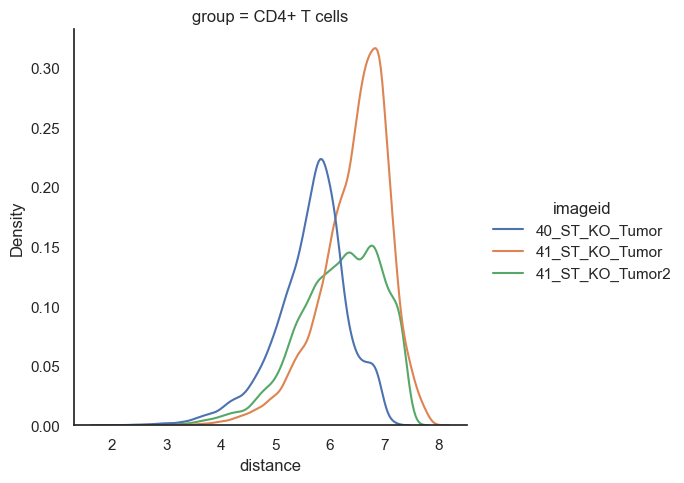

<Figure size 1000x400 with 0 Axes>

In [20]:
## Distribution plots of distance from each immune cell type to nearest tumor cell 
# 1 plot per immune cell type in distance_to
# Within each plot, split by ROI so you can compare across regions

for cell_type in distance_to:  # loop through each cell type one at a time -- so each plot is clear even when we have many cell types
    print(f"\n--Distance to {cell_type}--")

    fig = plt.figure(figsize=(10, 4))  # set figure size before calling scimap
    sm.pl.spatial_distance(
        adata1,
        method='distribution',   # show as distribution plots
        distance_from=distance_from,  # measure FROM this cell type
        distance_to=[cell_type],  # only this cell type
        imageid=roi_col, # split each violin by ROI
        label='spatial_distance',  # which stored result to use
        log=True, # log scale on the distance axis bc distance span a wide range
    )




    plt.gcf().set_size_inches(10, 4)
    plt.show()


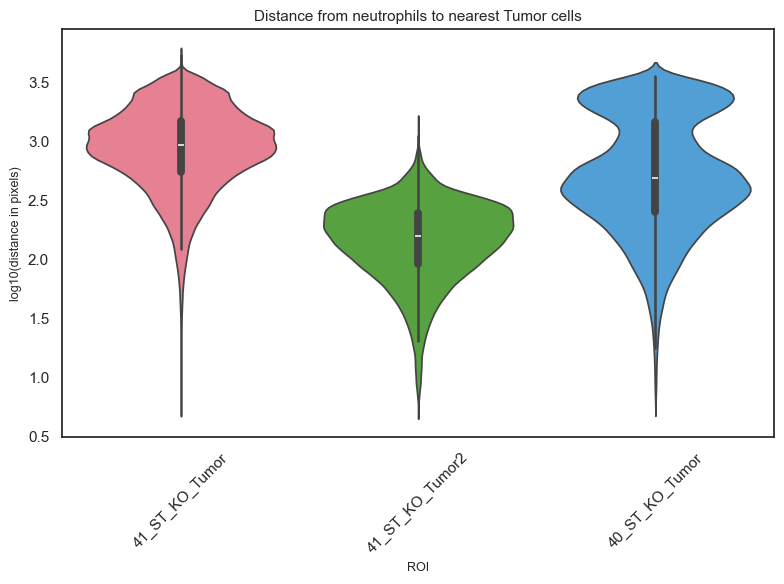

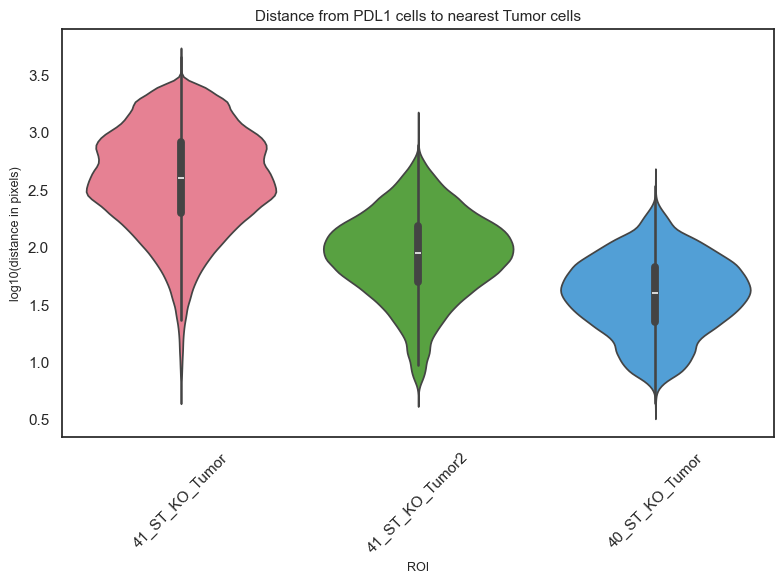

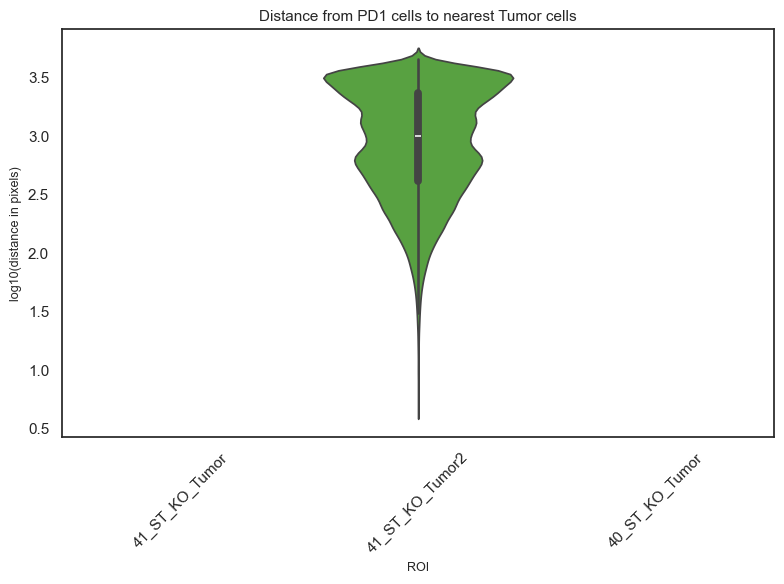

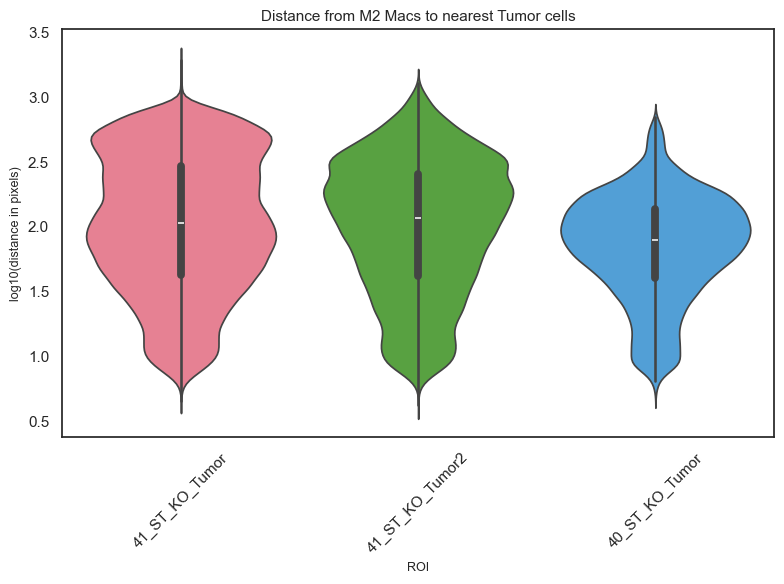

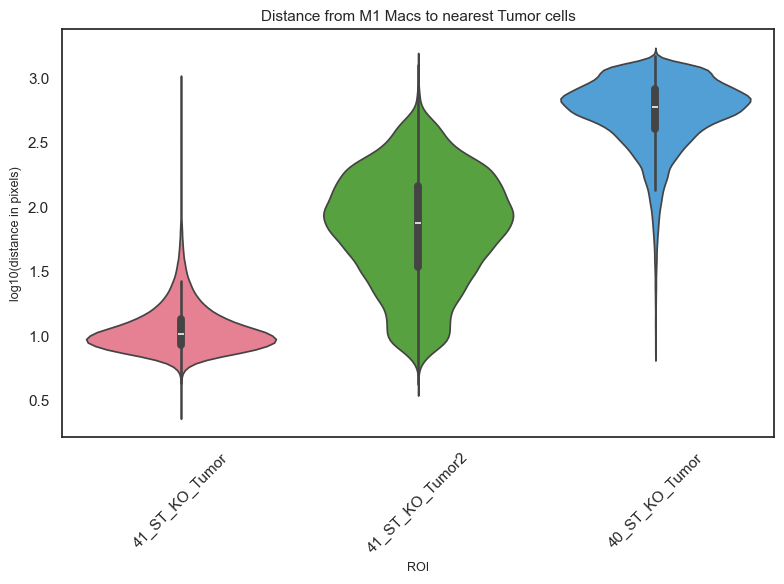

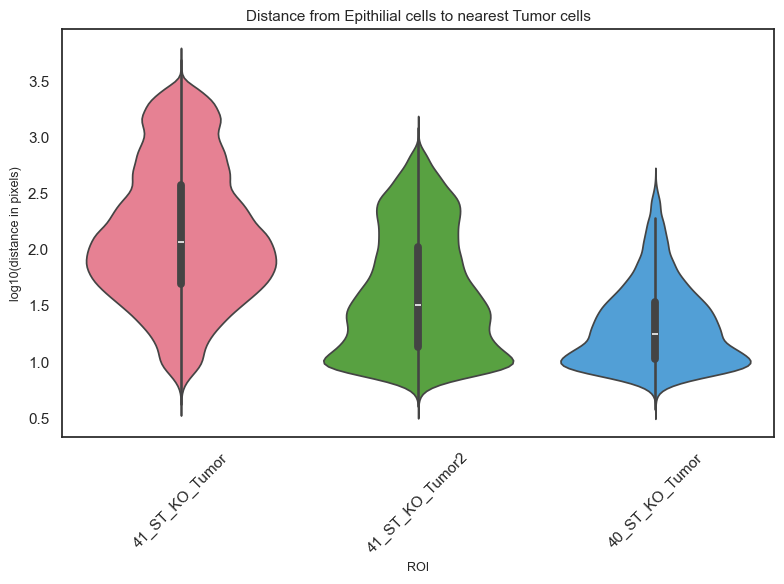

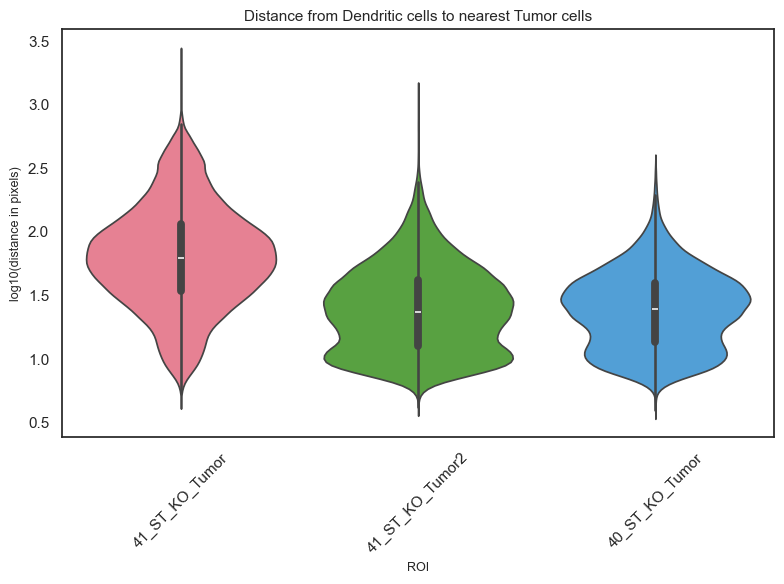

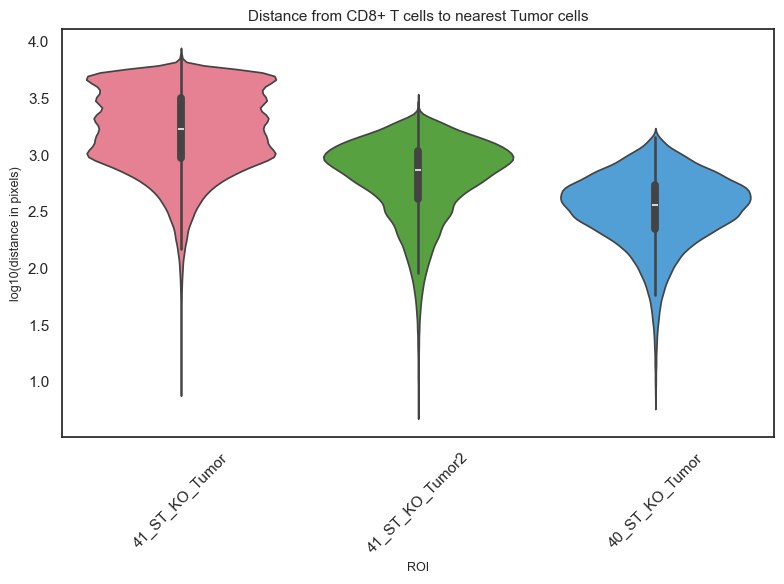

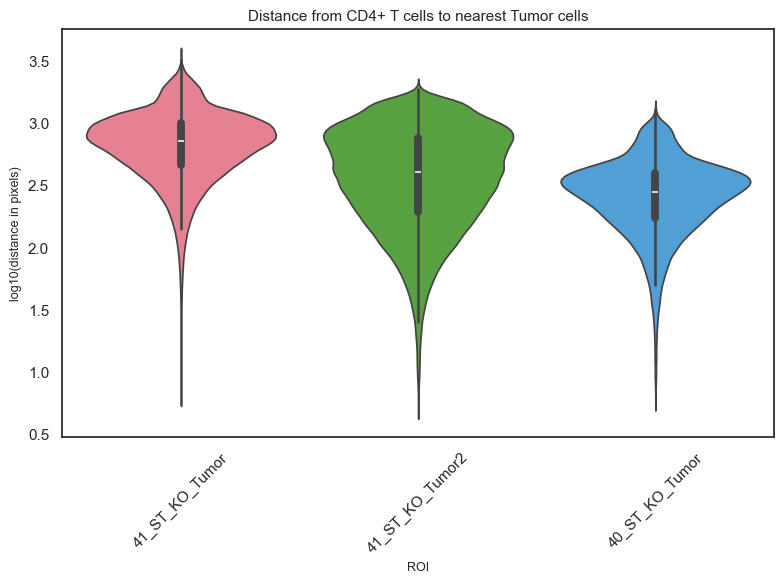

In [21]:
## Violin plots of spatial distances
# Pull the distance table out of adata1, where one row = one cell and one column per cell type showing distance to nearest
# cell of that type

dist_data = adata1.uns['spatial_distance'].copy()   # work on a copy

# add ROI column by looking up each cell's ROI label from adata1.obs
# dist_data.index contains the cell IDs and we use those to look up the matching ROI 
dist_data['ROI'] = adata1.obs.loc[dist_data.index, roi_col]

# Need to reshape from wide to long format because seaborn (use to make the plots) needs this
# wide is one row per cell, one column per cell type 
# long is one row per (cell + cell type) combo
dist_long = dist_data[distance_to + ['ROI']].melt(
    id_vars='ROI',  # keep ROI as an identifier column, don't need to reshape this one
    var_name='cell_type', # the column names (CD8+ T cells etc) are now going to be values in this new column
    value_name='distance' # the actual distance numbers will now go into this column
)

# Force the distances to be numeric 
# scimap sometimes stores distances as categorical data type (a lookup table) instead of numbers

dist_long['distance'] = pd.to_numeric(dist_long['distance'], errors='coerce')

# Log transform the distances (They span a wide range)
dist_long['log_distance'] = np.log10(dist_long['distance'])

# One subplot per immune cell type 
# within each subplot we have one violin per ROI

for cell_type in distance_to:  # loop through each immune cell type, one full figure per type (clear even w/ many cell types)
    fig, ax = plt.subplots(figsize=(8, 6))  # one full width figure per cell type
    # filter to only the rows for this specific cell type
    subset = dist_long[dist_long['cell_type'] == cell_type]
    sns.violinplot(
        data=subset,
        x='ROI',
        y='log_distance',
        inner='box',
        ax=ax,
        hue='ROI',
        palette='husl'
    )
    ax.set_title(f'Distance from {cell_type} to nearest {distance_from}', fontsize=11)
    ax.set_xlabel('ROI', fontsize=9)
    ax.set_ylabel('log10(distance in pixels)', fontsize=9)
    ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()

In [22]:
# Custom func to compute raw pairwise interaction counts using scipy, different from the scimap version above 
# this one counts actual occurrences -- for each cell, how many neighbors of each cell type fall within the radius

def spatial_interaction_working(adata, radius=interaction_radius, phenotype_col='phenotype', imageid_col='ROI'):
    """
    Purpose
    -------
    Count raw pairwise cell type interactions within a radius for each ROI

    Parameters
    ----------
    adata : AnnData
        The dataset, must have "X_centroid" and "Y_centroid" in adata.obs
    radius : int
        Neighbor search distance in pixels
    phenotype_col : str
        Name of the obs column w/ cell type labels
    imageid_col : str
        Name of the obs column that separates regions

    Returns
    -------
    pd.DataFrame
        One row per (ROI, cell type, neighbor cell type) w/ an interaction count
    """

    
    print('Starting spatial interaction analysis...')
    all_results = [] # empty list to collect results

    for roi in adata.obs[imageid_col].unique(): # loop over each unique ROI
        if roi == 'Other': # skip cells outside any ROI -- should be fine, this is another safety net
            continue                                    
        print(f'Processing {roi}...')            

        roi_data = adata[adata.obs[imageid_col] == roi].copy() # subset to just this ROI (independent copy)
        if len(roi_data) < 2: # need at least 2 cells to have a pair (safety check)
            continue  

        coords = np.array([  # build an array of positions -- 2 rows x (number of cells) columns
            roi_data.obs['X_centroid'].values,  # all x positions
            roi_data.obs['Y_centroid'].values  # all y positions
        ]).T.astype(np.float64)  # .T flips it to rows=cells

        phenotypes = roi_data.obs[phenotype_col].values  # cell type label for each cell, same order as coords

        # Find every pair of cells within radius of each other using a KD-tree instead of a
        # full NxN distance matrix -- cdist() needs memory proportional to cell_count^2, which
        # crashes with a MemoryError on any region with more than a few tens of thousands of
        # cells (confirmed: a 208,812-cell region needed 325 GiB for the full matrix alone).
        # query_pairs only ever materializes pairs that are actually within radius, so it
        # scales with how many neighbors cells actually have, not with cell count squared.
        tree = cKDTree(coords)
        pairs = tree.query_pairs(r=radius, output_type='ndarray')  # each unordered pair {i, j} appears once

        interaction_counts = {}  # dict for counting
        for i, j in pairs:  # every pair within radius is a neighbor relationship in BOTH directions --
                            # i.e. j is a neighbor of i, AND i is a neighbor of j -- same as the original
                            # center-cell loop counted both directions for every pair within radius
            key_ij = (roi, phenotypes[i], phenotypes[j])
            interaction_counts[key_ij] = interaction_counts.get(key_ij, 0) + 1
            key_ji = (roi, phenotypes[j], phenotypes[i])
            interaction_counts[key_ji] = interaction_counts.get(key_ji, 0) + 1

        for (roi_name, pheno1, pheno2), count in interaction_counts.items():  # unpack each cell neighbor pair 
            all_results.append({  # add a row to our results list
                'ROI': roi_name,
                'phenotype': pheno1,
                'neighbor_phenotype': pheno2,
                'interaction_count': count
            })
        print(f'{roi} done!')                 

    results_df = pd.DataFrame(all_results) # turn the list of dicts into a dataframe
    print(f'\nComplete! {len(results_df)} interaction pairs found')  
    return results_df  
    

print(f"Function 'spatial_interaction_working' defined")

Function 'spatial_interaction_working' defined


In [23]:
# Here we actually run the raw counts function
spatial_results = spatial_interaction_working(
    adata1,
    radius=interaction_radius,
    phenotype_col=phenotype_col,
    imageid_col=roi_col
)

Starting spatial interaction analysis...
Processing 41_ST_KO_Tumor...
41_ST_KO_Tumor done!
Processing 41_ST_KO_Tumor2...
41_ST_KO_Tumor2 done!
Processing 40_ST_KO_Tumor...
40_ST_KO_Tumor done!

Complete! 549 interaction pairs found


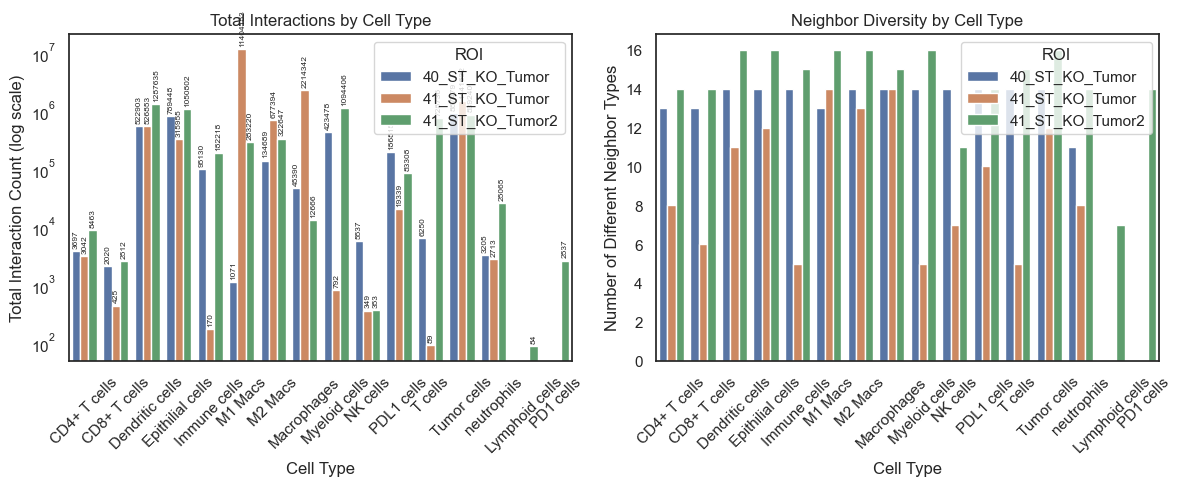

In [26]:
# Left shows the total interactions per cell type per ROI
# Right shows neighbor diversity -- so how many DIFFERENT cell types does each type interact with

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5)) # two subplots side by side

summary = (spatial_results  # start from the results table
           .groupby(['ROI', 'phenotype'])  # group rows by ROI and cell type
           ['interaction_count']  # we care about the count column
           .sum()   # total interactions per group
           .reset_index())  # turn the grouped result back into a flat table

sns.barplot(data=summary, x='phenotype', y='interaction_count',  # bar plot of totals
            hue='ROI', ax=ax1)     # one bar color per ROI, draw on left subplot
ax1.set_yscale('log')  # log scale -- counts here span a wide range (e.g. M1 Macs vs PD1
                       # cells), so a linear axis makes high-interaction cell types dwarf
                       # low-frequency ones, even though we want to directly compare all of them
for container in ax1.containers:  # one container per hue (ROI) group
    ax1.bar_label(container, fmt='%.0f', fontsize=6, rotation=90, padding=2)  # exact count on top of each bar,
                                                                              # since the log scale makes it hard to read small differences by eye
ax1.set_title('Total Interactions by Cell Type')  
ax1.set_xlabel('Cell Type')                           
ax1.set_ylabel('Total Interaction Count (log scale)')           
ax1.tick_params(axis='x', rotation=45)   # rotate labels

diversity = (spatial_results    # start from results again
             .groupby(['ROI', 'phenotype'])   # group by ROI and cell type
             ['neighbor_phenotype']  # look at the neighbor type column
             .nunique()   # count how many DIFFERENT neighbor types
             .reset_index()) # flatten back to a table

diversity.columns = ['ROI', 'phenotype', 'neighbor_diversity']  # rename for clarity
sns.barplot(data=diversity, x='phenotype', y='neighbor_diversity',  # bar plot of diversity
            hue='ROI', ax=ax2)  

ax2.set_title('Neighbor Diversity by Cell Type')       
ax2.set_xlabel('Cell Type')                          
ax2.set_ylabel('Number of Different Neighbor Types')    
ax2.tick_params(axis='x', rotation=45)                  

plt.tight_layout()
plt.show()

In [27]:
## Voronoi tissue map: every cell gets drawn as a colored polygon instead of just a dot
# One image per region in voronoi_rois

for roi in voronoi_rois:
    print(f'--- {roi} ---')

    # Subset to just this region
    adata_roi = adata1[adata1.obs[roi_col] == roi].copy() # boolean mask: keep only cells in this region + work on a copy

    # Downsample for speed -- Voronoi computes + draws one polygon per cell, so it gets slow
    # past tens of thousands of cells. Stratified by phenotype_col so rare cell types aren't
    # sampled away and the composition still looks representative at a glance.
    if voronoi_max_cells is not None and adata_roi.n_obs > voronoi_max_cells:
        frac = voronoi_max_cells / adata_roi.n_obs
        sampled_idx = (adata_roi.obs
                       .groupby(phenotype_col, group_keys=False)
                       .sample(frac=frac, random_state=0)  # fixed seed so the plot is reproducible across reruns
                       .index)
        adata_roi = adata_roi[sampled_idx].copy()
        print(f'Downsampled to {adata_roi.n_obs:,} cells for faster Voronoi rendering (voronoi_max_cells={voronoi_max_cells:,})')

    print(f'Plotting voronoi for {roi}: {adata_roi.n_obs:,} cells')

    voronoi_filename = f'voronoi_{roi}.png'  # separate filename per region so plots don't overwrite each other

    # Run scimap voronoi and save directly to a file 
    # Here we save to a file instead of displaying because scimap always opens its own figure internally 
    # if we just call plt.show() the legend ends up on a separate empty plot
    sm.pl.voronoi(
        adata_roi,
        color_by=phenotype_col, # color by cell type
        voronoi_edge_color='black',  # thin black border between polygons
        voronoi_line_width=0.3,  
        voronoi_alpha=0.8, # polygon opacity
        size_max=voronoi_size_max, # maximum area any single polygon is allowed to be
        overlay_points=None, # don't draw dots on top of polygons (cleaner)
        plot_legend=False, # turn OFF scimap's built-in legend, draw our own below
        legend_size=6,
        colors=customColors, # use our defined colors
        saveDir=voronoi_save_dir, # folder to save the image to
        fileName=voronoi_filename # filename for the saved image
    )
    #  define the actual (final) path name after scimap saves the image
    voronoi_actual_path = os.path.join(voronoi_save_dir, voronoi_filename)

    # Now, we reload the saved image and add our legend on top 
    # Here we get full control of the figure because we make it ourselves with plt.subplots()
    # scimap's figure is gone, we're working with a flat image loaded from where we saved it

    # Load from that path
    img = Image.open(voronoi_actual_path)

    fig, ax = plt.subplots(figsize=(12, 12), dpi=200)  # create our own high res figure
                                                    
    ax.imshow(img) # draw the voronoi image onto our axes
    ax.set_xticks([]) # hide x axis tick marks 
    ax.set_yticks([]) # hide y-axis tick marks

    # Finally build and add the legend manually 
    # mpatches.Patch makes one colored rectangle per cell type
    # Filter to only include cell types that actually exist in this region
    legend_patches = [
        mpatches.Patch(color=color, label=cell_type)           # colored square + label
        for cell_type, color in customColors.items()           # loop through all defined colors
        if cell_type in adata_roi.obs[phenotype_col].values    # only include if present in this region
    ]

    ax.legend(
        handles=legend_patches,  # the list of colored squares we just built
        loc='upper right',  # position on the plot
        fontsize=11,              
        framealpha=0.9, # legend box background opacity 
        title='Cell Type',      
        title_fontsize=12       
    )

    ax.set_title(roi, fontsize=14)  # label which region this is, since there's now more than one

    plt.tight_layout() # auto adjust spacing so nothing gets cut off
    # Overwrite the bare version scimap saved above with this one -- this is the actual
    # figure the notebook displays (image + our own legend), so it's the one that should
    # end up on disk. Save before show(), since Jupyter's inline backend closes the figure
    # as part of showing it, so saving after show() would silently save a blank figure instead
    plt.savefig(voronoi_actual_path, dpi=200, bbox_inches='tight')
    plt.show()

--- 41_ST_KO_Tumor1 ---
Plotting voronoi for 41_ST_KO_Tumor1: 0 cells


ValueError: max() arg is an empty sequence

In [ ]:
## First, find dense spatial clusters of each cell type 
# Looks at every cell and checks what fraction of its neighbors are the same cell type as itself
# If that fraction is >= aggregate_purity then the cell gets labeled with its cell type as a "pure aggregate" region
# If the fraction is below --> gets labeled "other" meaning it's in a mixed region 

adata1 = sm.tl.spatial_aggregate(
    adata1,
    phenotype=phenotype_col,  # column w/ cell type labels
    method='radius',  # define neighborhood by distance
    radius=aggregate_radius,   
    purity=aggregate_purity,    
    imageid=roi_col, # run separately per ROI
    label=aggregate_label # name of the new column added 
)

print('Spatial aggregation complete!')
print(f'New column "{aggregate_label}" added to adata1.obs')
print('\nAggregate region counts:')
print(adata1.obs[aggregate_label].value_counts())


In [ ]:
# Visualize aggregate regions on the same region(s) as before 
# same approach as the voronoi cell above but now we color by aggregate_label instead of phenotype
# so instead of seeing individual cell types you see which regions are
# dense clusters vs mixed -- one image per region in aggregate_rois

# ‼️Review the types of aggregate regions from the cell output above -- now assign them colors:‼️

agg_voronoi_colors = {
    'non-significant':  '#cccccc',
    'M1 Macs':           '#118ab2',
    'Tumor cells':        '#ef476f',
    'Myeloid cells':      '#ff9f1c',
    'Macrophages':        '#06d6a0',
    'M2 Macs':            '#80ed99',
    'Dendritic cells':    '#ffd166',
    'T cells':            '#9b5de5',
    'Epithilial cells':   '#4cc9f0',
    'CD4+ T cells':       '#7209b7',
    'Immune cells':       '#00bbf9',
    'PDL1 cells':         '#fee440',
    'neutrophils':        '#fb5607'}

for roi in aggregate_rois:
    print(f'--- {roi} ---')

    # subset to this region
    adata_roi_agg = adata1[adata1.obs[roi_col] == roi].copy()

    # Downsample for speed, same as the phenotype voronoi above -- stratified by
    # aggregate_label this time since that's what's being visualized here
    if voronoi_max_cells is not None and adata_roi_agg.n_obs > voronoi_max_cells:
        frac = voronoi_max_cells / adata_roi_agg.n_obs
        sampled_idx = (adata_roi_agg.obs
                       .groupby(aggregate_label, group_keys=False)
                       .sample(frac=frac, random_state=0)  # fixed seed so the plot is reproducible across reruns
                       .index)
        adata_roi_agg = adata_roi_agg[sampled_idx].copy()
        print(f'Downsampled to {adata_roi_agg.n_obs:,} cells for faster Voronoi rendering (voronoi_max_cells={voronoi_max_cells:,})')

    # save the voronoi colored by aggregate regions
    agg_filename = f'voronoi_aggregate_{roi}.png'  # separate filename per region so plots don't overwrite each other

    sm.pl.voronoi(
        adata_roi_agg,
        color_by=aggregate_label,   # color by aggregate region, not phenotype
        voronoi_edge_color='facecolor',
        voronoi_line_width=0.3,
        voronoi_alpha=0.8,
        size_max=voronoi_size_max,
        overlay_points=None,
        plot_legend=False,
        legend_size=6,
        colors=agg_voronoi_colors,
        saveDir=voronoi_save_dir,
        fileName=agg_filename
    )

    # build the actual path the same way as before
    agg_actual_path = os.path.join(voronoi_save_dir, agg_filename)

    # reload and add legend same as before
    img_agg = Image.open(agg_actual_path)

    fig, ax = plt.subplots(figsize=(12, 12), dpi=200)
    ax.imshow(img_agg)
    ax.set_xticks([])
    ax.set_yticks([])

    # build legend from the aggregate labels that actually exist in this region
    legend_patches = [
        mpatches.Patch(color=color, label=label)
        for label, color in agg_voronoi_colors.items()
        if label in adata_roi_agg.obs[aggregate_label].values  # mostly same as before
    ]

    ax.legend(handles=legend_patches, loc='upper right',
              fontsize=11, framealpha=0.9,
              title='Aggregate Region', title_fontsize=12)

    ax.set_title(roi, fontsize=14)  # label which region this is, since there's now more than one

    plt.tight_layout()
    # Overwrite the bare version scimap saved above with this one (image + our own legend)
    # -- save before show(), since Jupyter's inline backend closes the figure as part of
    # showing it, so saving after show() would silently save a blank figure instead
    plt.savefig(agg_actual_path, dpi=200, bbox_inches='tight')
    plt.show()

In [ ]:
## Here we look at how much of each ROI is dense aggregate vs mixed
# counts what fraction of cells in each ROI fall into a pure aggregate vs the mixed other category
# useful for comparing ROIs

agg_counts = (adata1.obs
              .groupby([roi_col, aggregate_label], observed=True) # observed=True avoids creating a phantom
                  # zero-count row for every (ROI, aggregate_label) combination that doesn't actually occur
              .size() # count cells per group
              .reset_index(name='count')) # turn into a flat table

# calculate fraction within each ROI so bars are comparable regardless of raw ROI size
agg_counts['fraction'] = (agg_counts
                          .groupby(roi_col, observed=True)['count'] # within each ROI
                          .transform(lambda x: x / x.sum())) # lambda func to divide each count by the ROI total

fig, ax = plt.subplots(figsize=(8, 5))

agg_palette = {**customColors, 'non-significant': '#999999'} # use our defined colors bc the default ones are too similar to each other

sns.barplot(
    data=agg_counts,
    x=roi_col, # one group of bars per ROI
    y='fraction',   # height = fraction of cells in this aggregate type
    hue=aggregate_label,  # one bar color per aggregate label
    ax=ax,
    palette = agg_palette
)

ax.set_title('Fraction of cells in dense aggregate regions per ROI', fontsize=12)
ax.set_xlabel('ROI', fontsize=10)
ax.set_ylabel('Fraction of cells', fontsize=10)
ax.tick_params(axis='x', rotation=45)
ax.legend(title='Aggregate type', bbox_to_anchor=(1.05, 1),  # legend outside the plot so it doesn't cover the bars
          loc='upper left', fontsize=9)                       

plt.tight_layout()
plt.show()